In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting the plant disease classification process...
Extracting dataset...
Extraction complete!
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.
Number of classes: 38
Creating model...
Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 132s 240ms/step - accuracy: 0.1917 - loss: 3.0774 - val_accuracy: 0.3631 - val_loss: 2.2591 - learning_rate: 9.4928e-04
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 108s 212ms/step - accuracy: 0.3930 - loss: 2.1312 - val_accuracy: 0.4870 - val_loss: 1.6948 - learning_rate: 8.9991e-04
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 110s 217ms/step - accuracy: 0.5283 - loss: 1.6198 - val_accuracy: 0.6208 - val_loss: 1.2487 - learning_rate: 8.5292e-04
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 111s 218ms/step - accuracy: 0.6007 - loss: 1.3440 - val_accuracy: 0.5924 - val_loss: 1.3399 - learning_rate: 8.0838e-04
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 110s 217ms/step - accuracy: 0.6551 - loss: 1.1460 - val_accuracy: 0.6365 - val_loss: 1.1736 - learning_rate: 7.6617e-04
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 112s 220ms/step - accuracy: 0.6919 - loss: 1.0145 - val_accuracy: 0.7568 - val_loss: 0.7946 - learning_rate: 7.2624e-04
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 

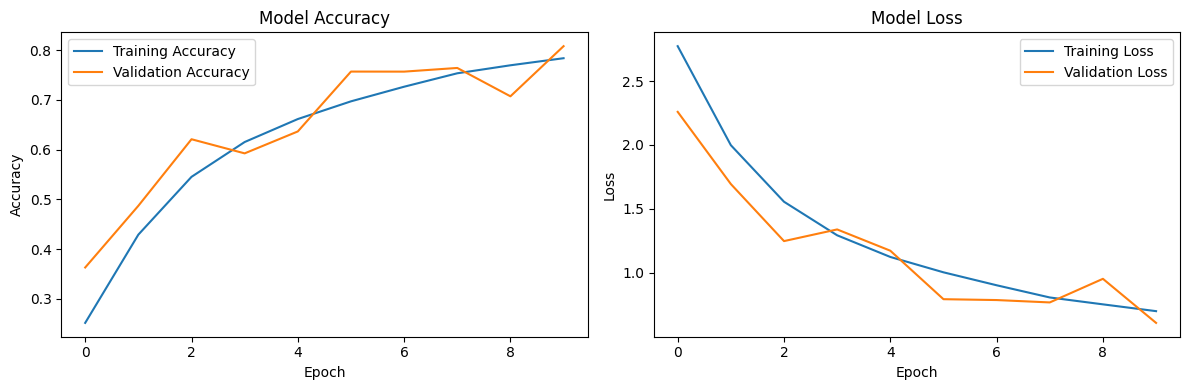

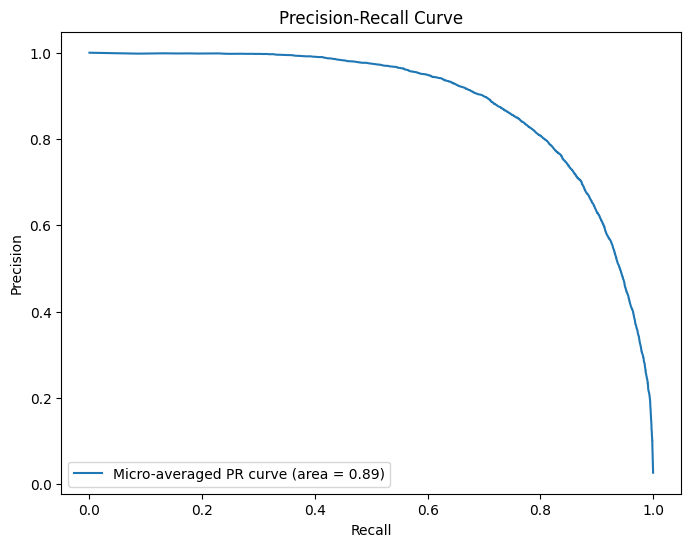


Final Accuracies:
Training Accuracy: 0.7836
Validation Accuracy: 0.8078
Testing Accuracy: 0.7974


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mount Google Drive
drive.mount('/content/drive')

# Extract the zip file
def extract_dataset():
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT (1).zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete!")
    else:
        print("Dataset already extracted!")
    return extract_path

# Create modified UNet for classification (smaller version)
def create_classification_unet(input_size=(96, 96, 3), num_classes=38):
    inputs = Input(input_size)

    # Encoder (reduced filters)
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, 3, activation='relu', padding='same')(pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, 3, activation='relu', padding='same')(pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bridge
    conv4 = Conv2D(256, 3, activation='relu', padding='same')(pool3)

    # Classification head
    gap = GlobalAveragePooling2D()(conv4)
    dense1 = Dense(128, activation='relu')(gap)
    dropout = Dropout(0.5)(dense1)
    output = Dense(num_classes, activation='softmax')(dropout)

    model = Model(inputs=inputs, outputs=output)
    return model

# Load and preprocess data from directory
def load_data(base_path, img_size=(96, 96)):
    data_generator = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,  # Add data augmentation
        rotation_range=20
    )

    # Setup data generators with optimized parameters
    train_generator = data_generator.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=64,  # Increased batch size
        class_mode='categorical',
        shuffle=True
    )

    # No augmentation for validation and test
    val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=64,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=64,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

def train_and_evaluate():
    # Extract dataset
    base_path = extract_dataset()

    # Load data
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(base_path)
    num_classes = len(train_generator.class_indices)
    print(f"Number of classes: {num_classes}")

    # Create and compile model
    print("Creating model...")
    model = create_classification_unet(input_size=(96, 96, 3), num_classes=num_classes)

    # Use a higher learning rate with decay
    initial_learning_rate = 0.001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=1000, decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Add callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2
        )
    ]

    # Train model
    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Get predictions for PR curve
    y_pred = model.predict(test_generator)
    y_test = test_generator.labels
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Plot training history
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot PR curve
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_pred.ravel())

    plt.plot(recall["micro"], precision["micro"], label=f'Micro-averaged PR curve (area = {auc(recall["micro"], precision["micro"]):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

if __name__ == "__main__":
    print("Starting the plant disease classification process...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")